### Read SNOWPACK Output at All Sites with HRRR-AK WY2020-WY2025
* including the lapse-rate corrected simulations

created by Cassie Lumbrazo\
last updated: July 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# HRRR-AK Lapse-rate Files 
ds_snowpack_hrrrak_lapserate_ppsa, header_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_tram, header_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_lapserate_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_heen, header_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_lapserate_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now
ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

# Met HRRR-AK Lapse-rate Files
ds_snowpack_met_hrrrak_lapserate_ppsa, header_met_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
# ds_snowpack_met_hrrrak_lapserate_tram, header_met_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_lapserate_tram_WY2023-WY2025_base.smet")
ds_snowpack_met_hrrrak_lapserate_heen, header_met_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_lapserate_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025

/tmp/ipykernel_1626021/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626021/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626021/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626021/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1626021/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df 

### Open Observations

In [5]:
# open observations

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))


# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

In [6]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
hrrrak_lapserate_color = 'tab:orange'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

In [7]:
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-09-01", "2022-09-30"))
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-09-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-09-01", "2025-09-30"))

## Add in the model simulations one-by-one

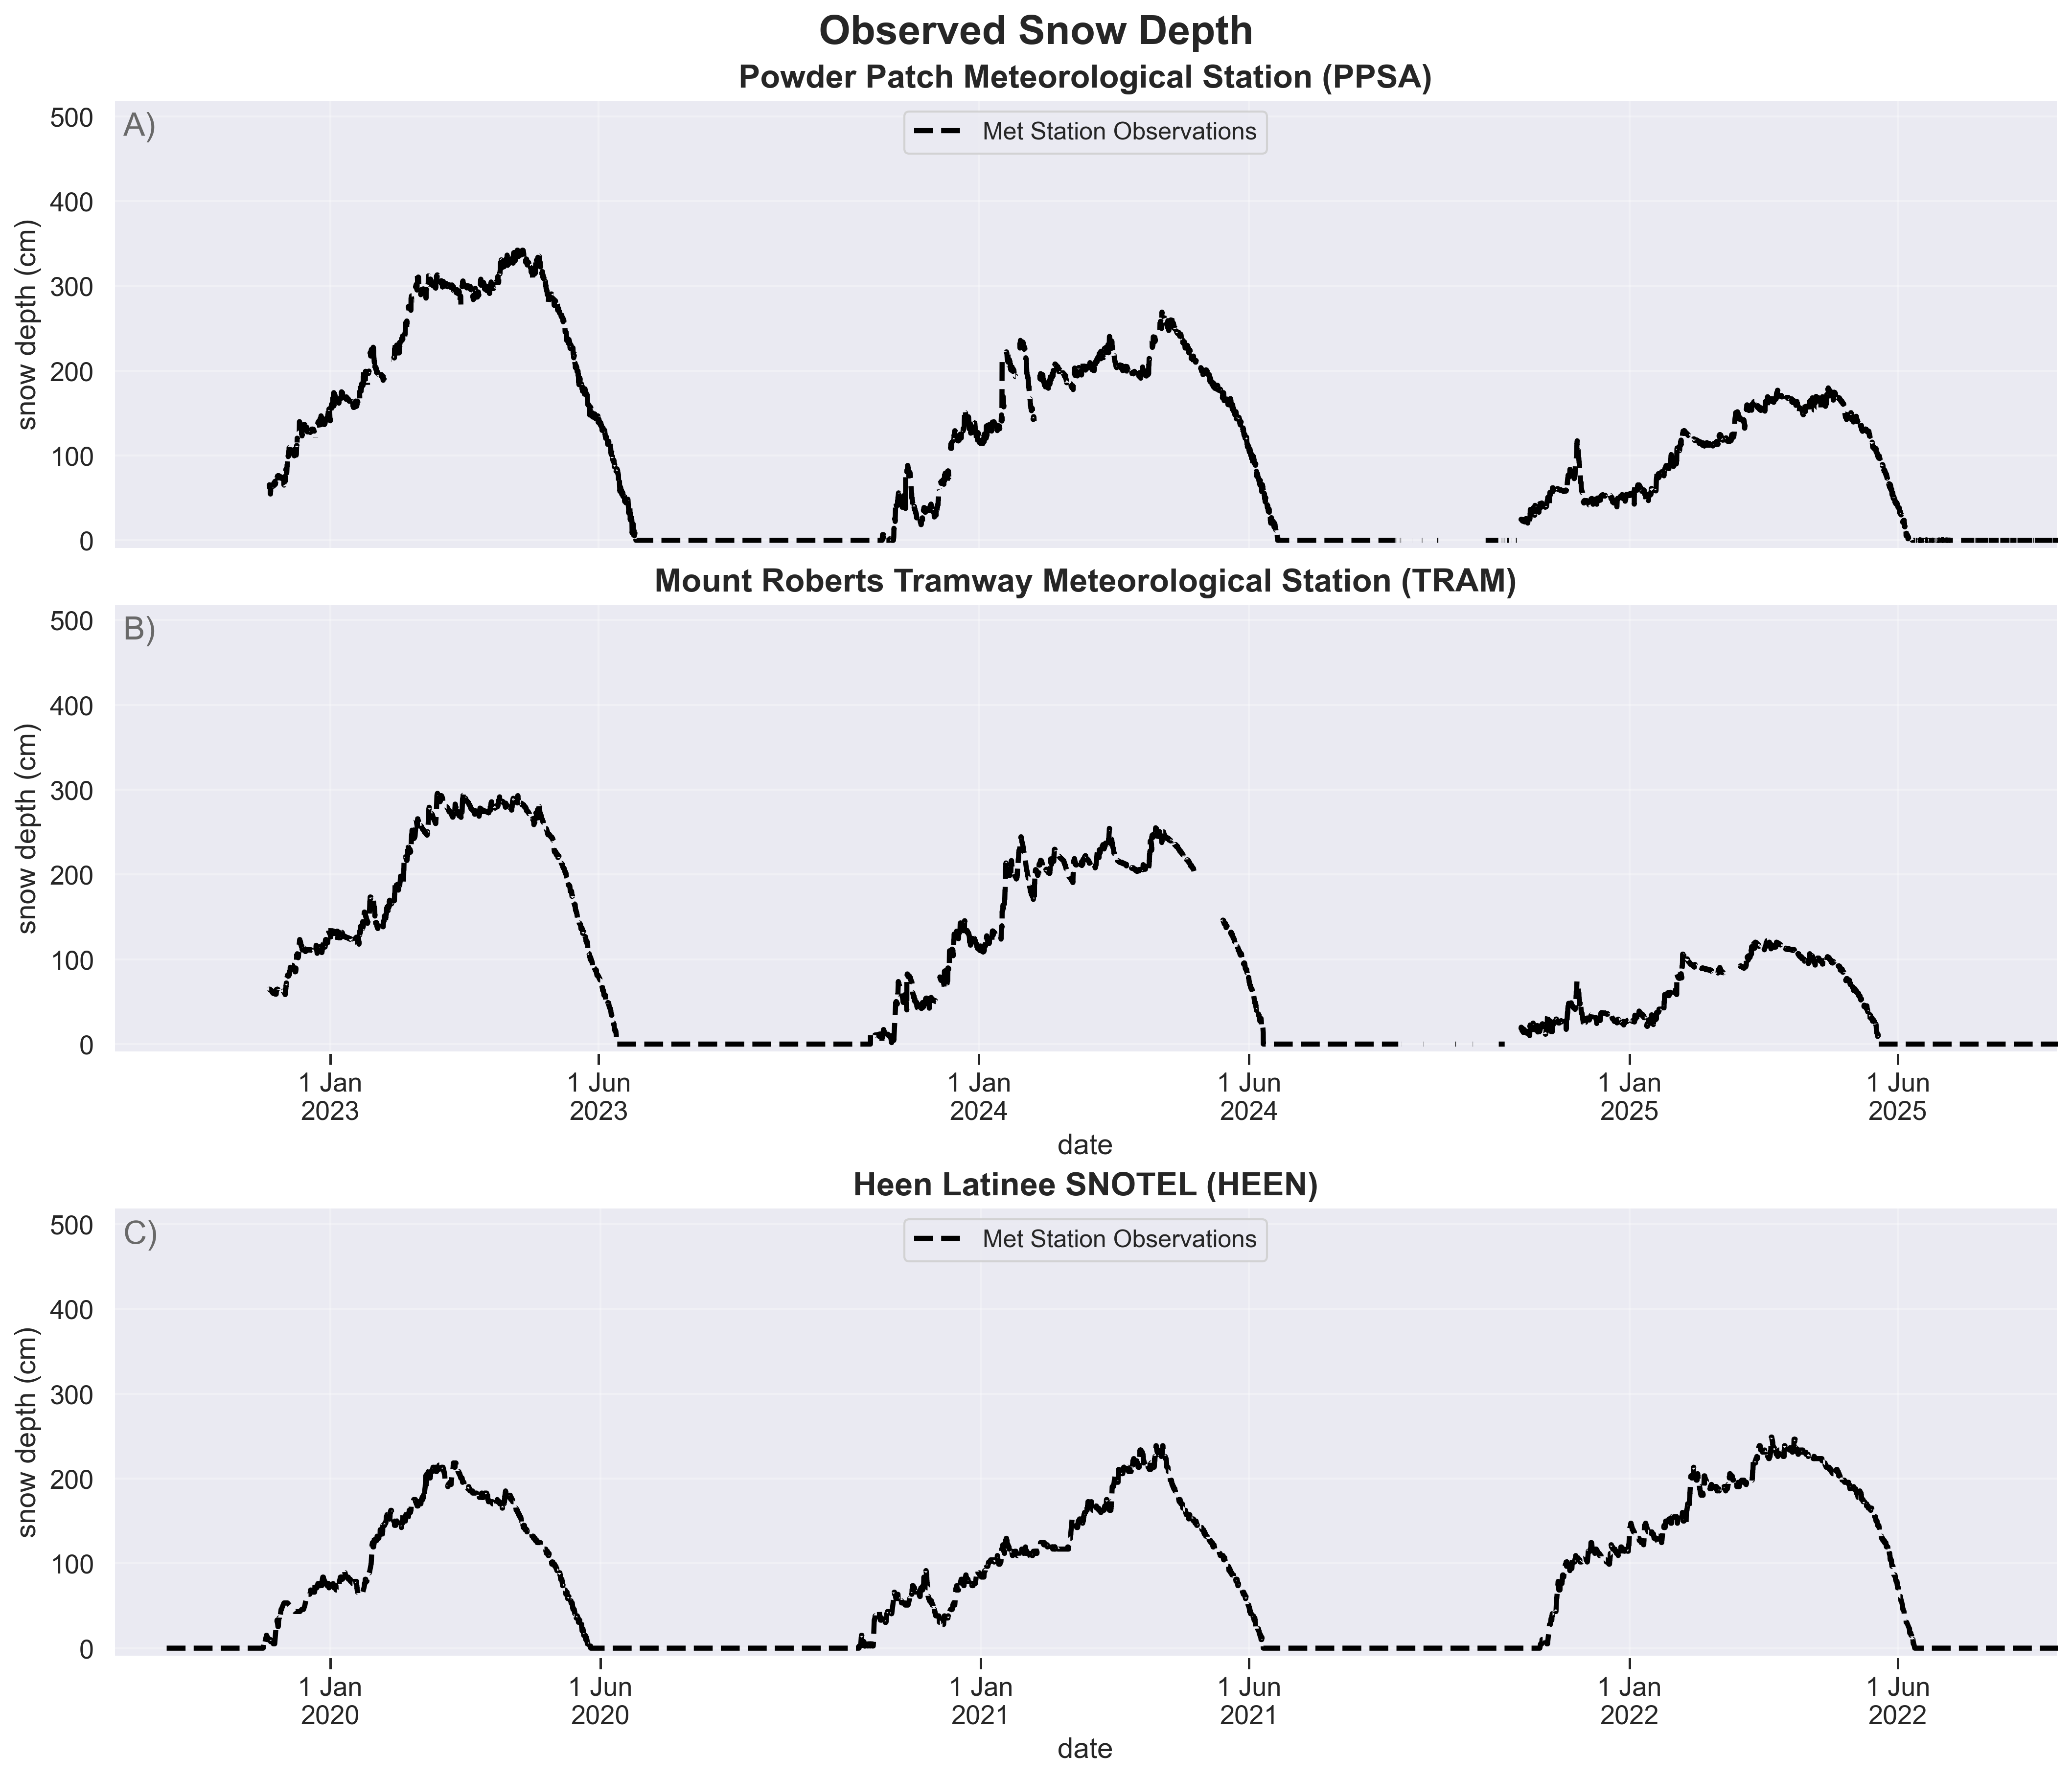

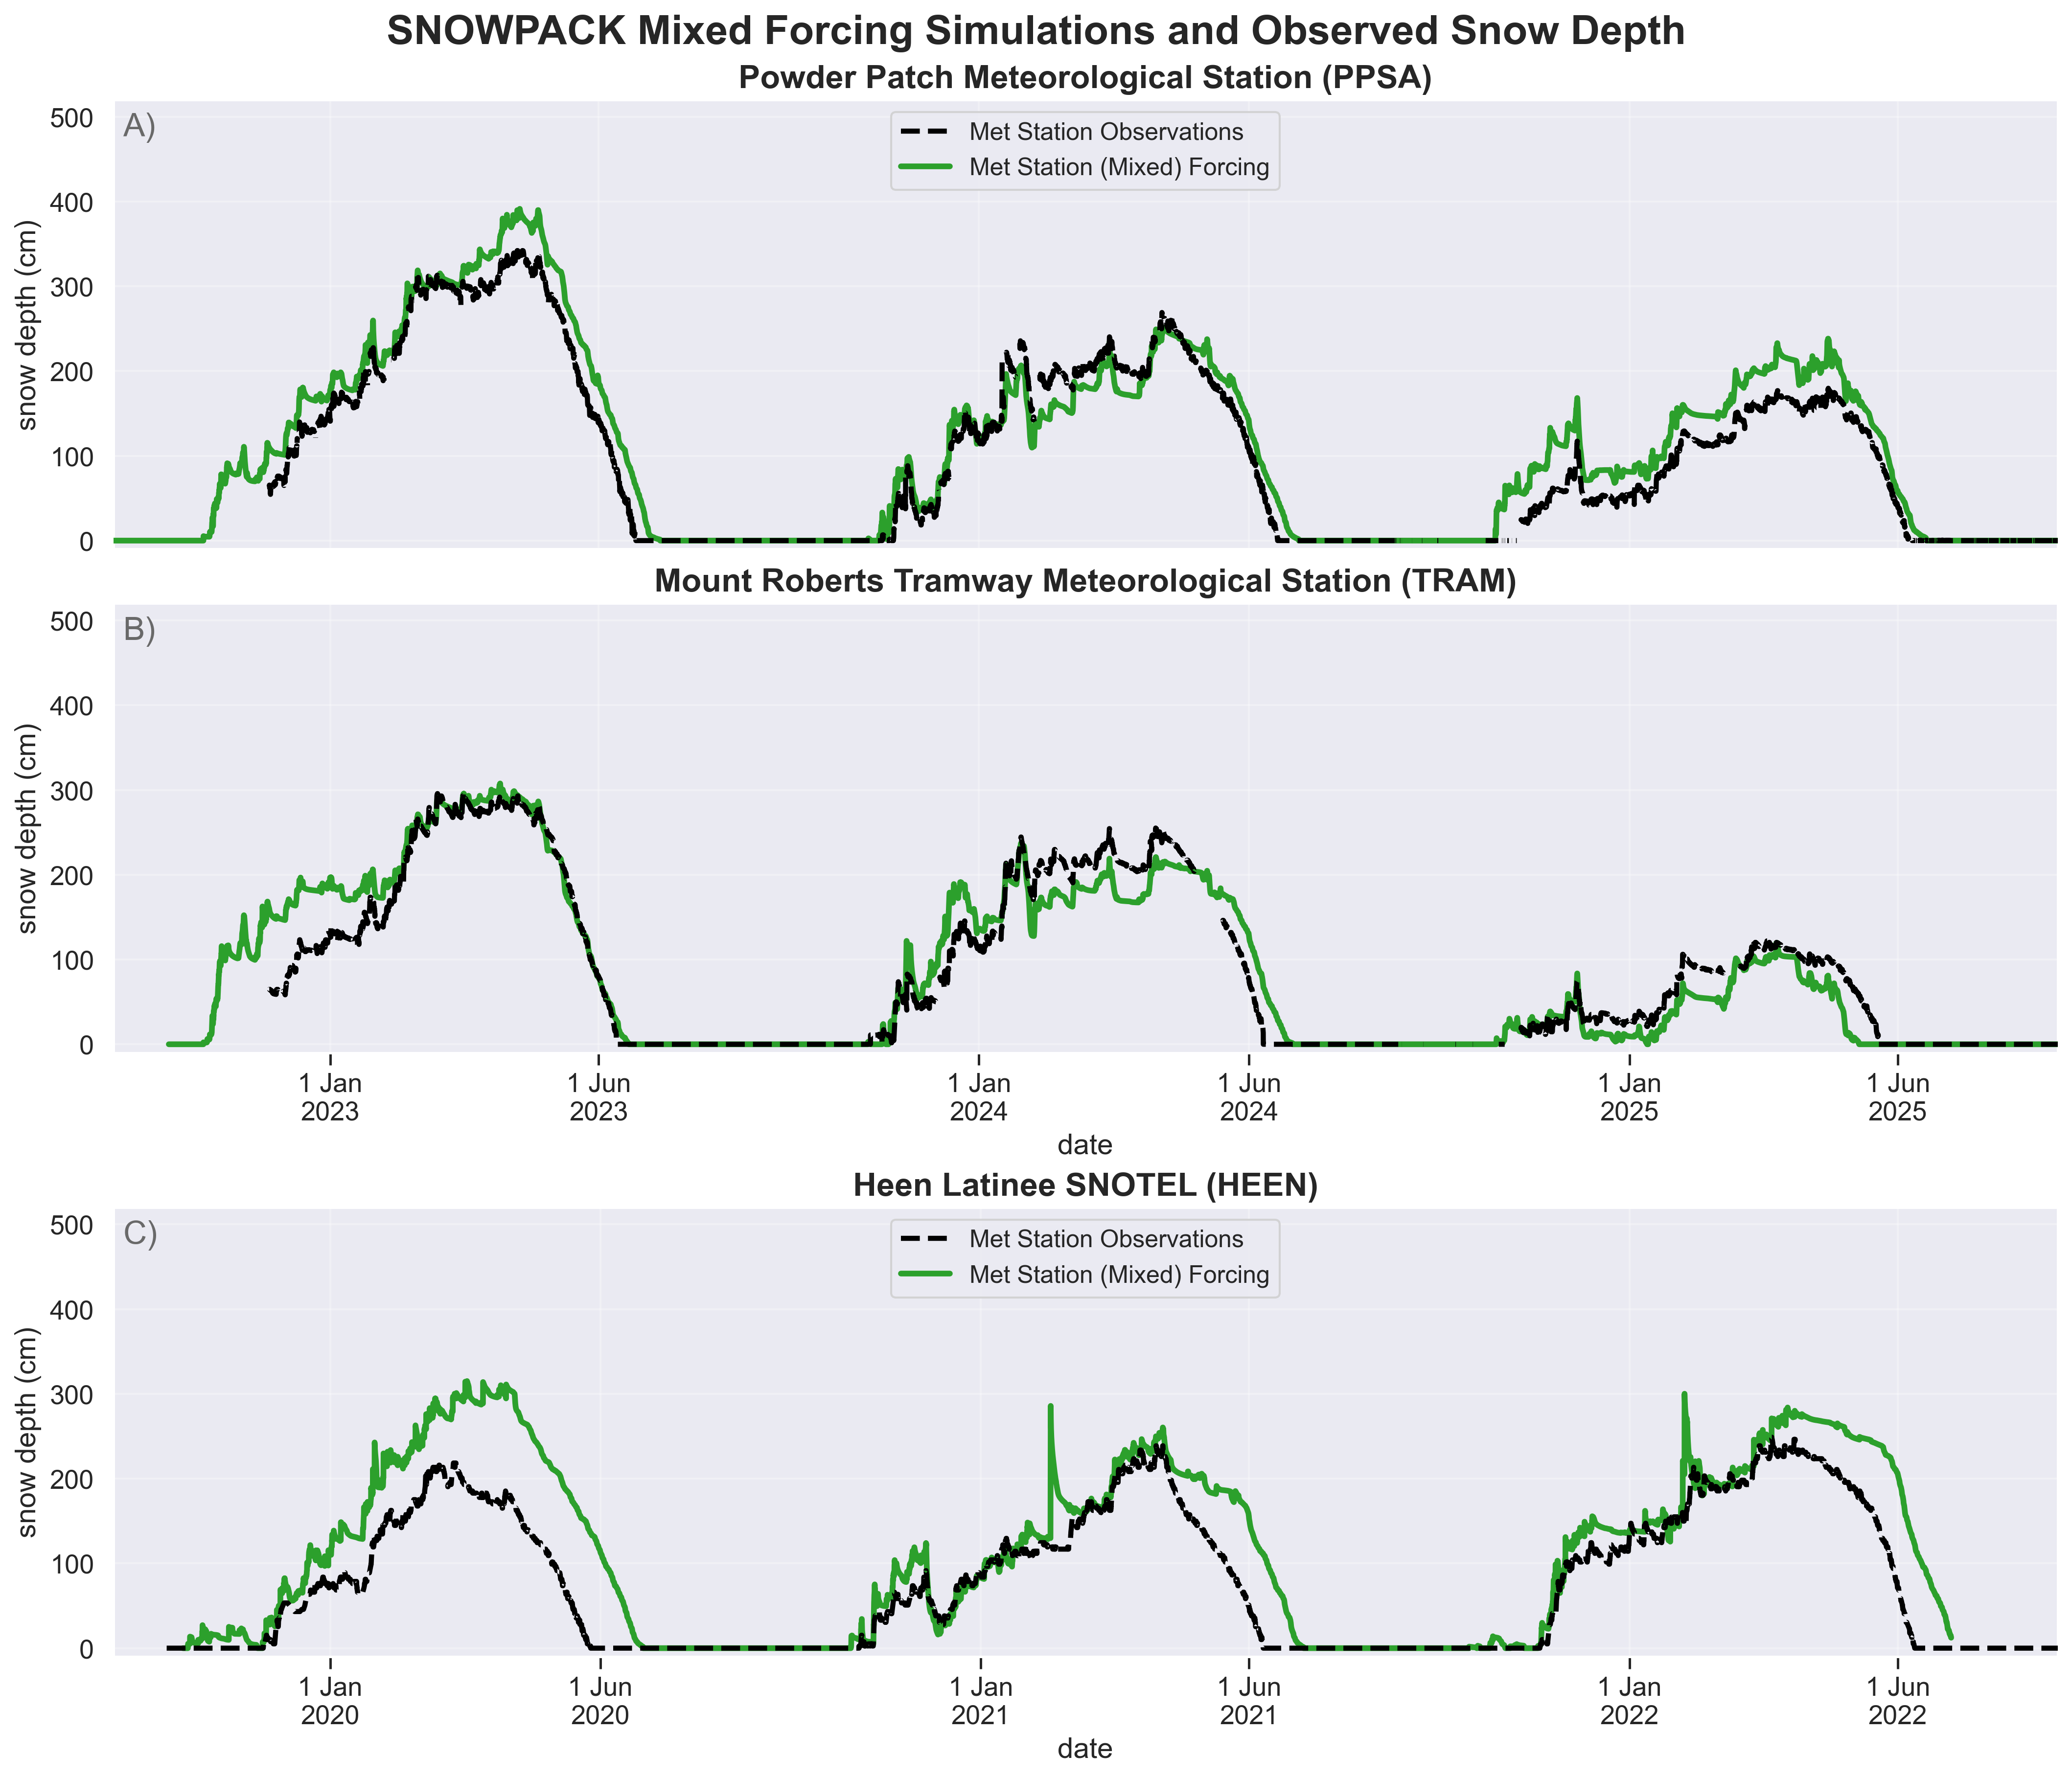

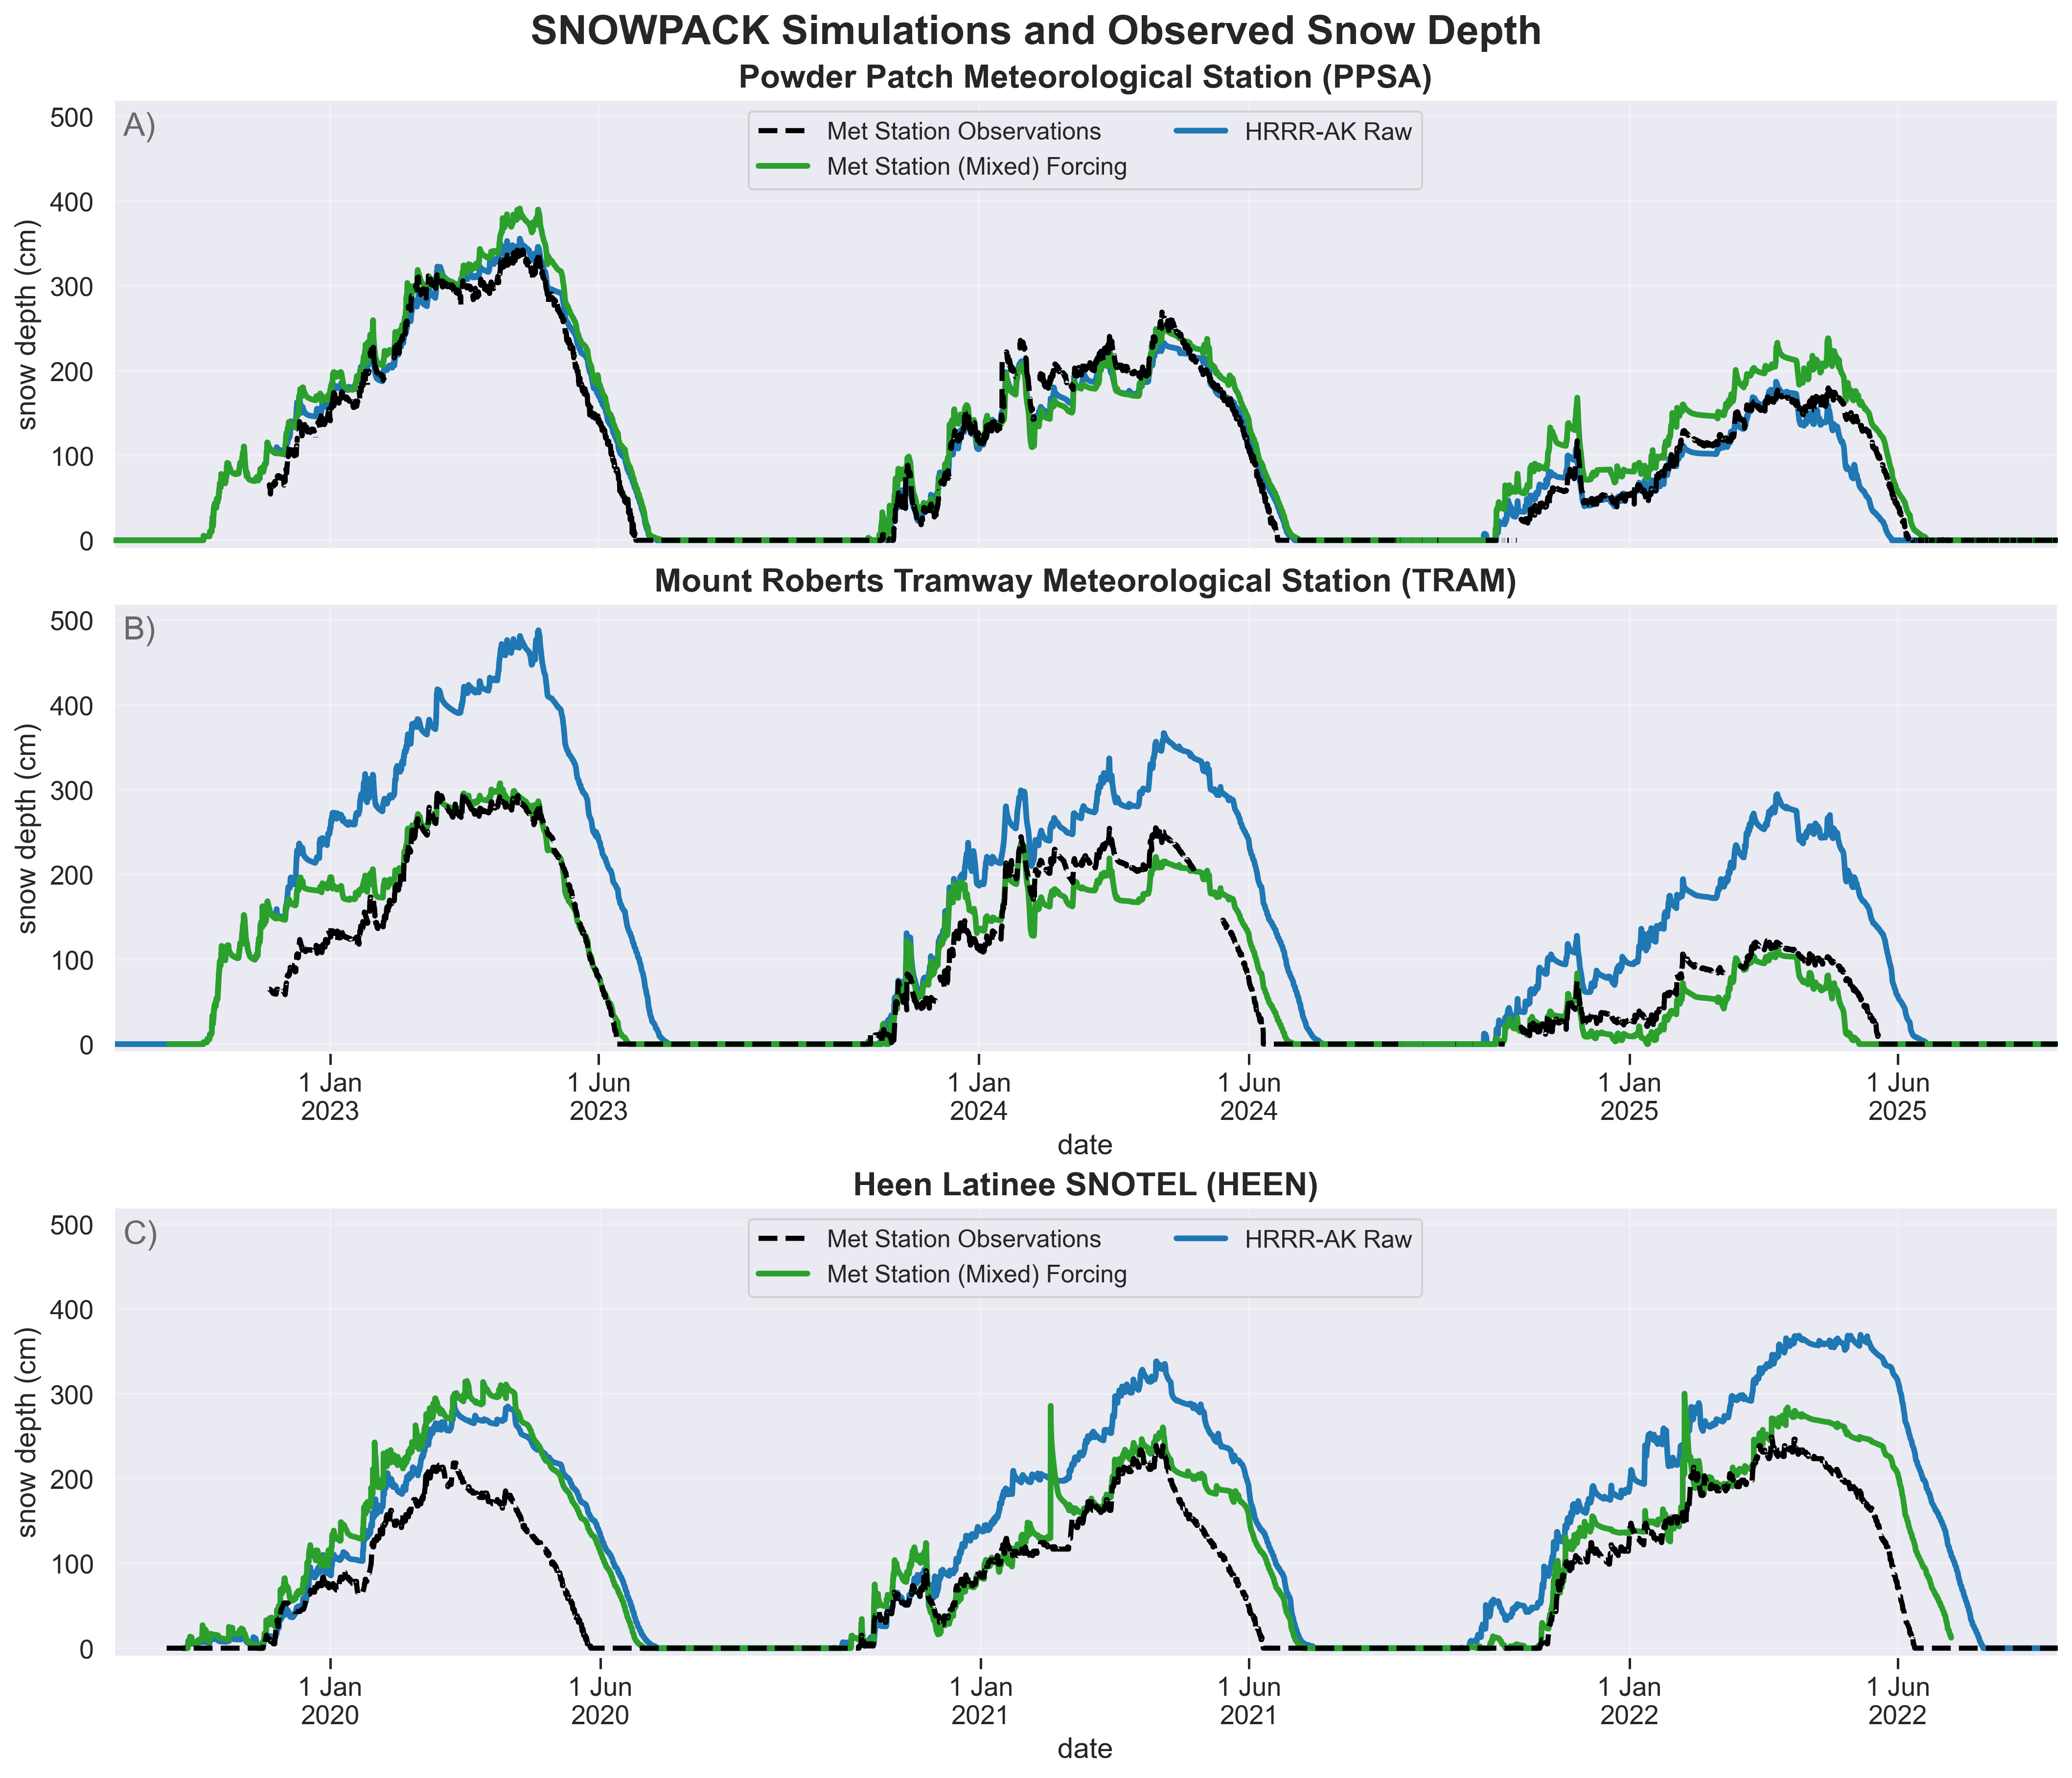

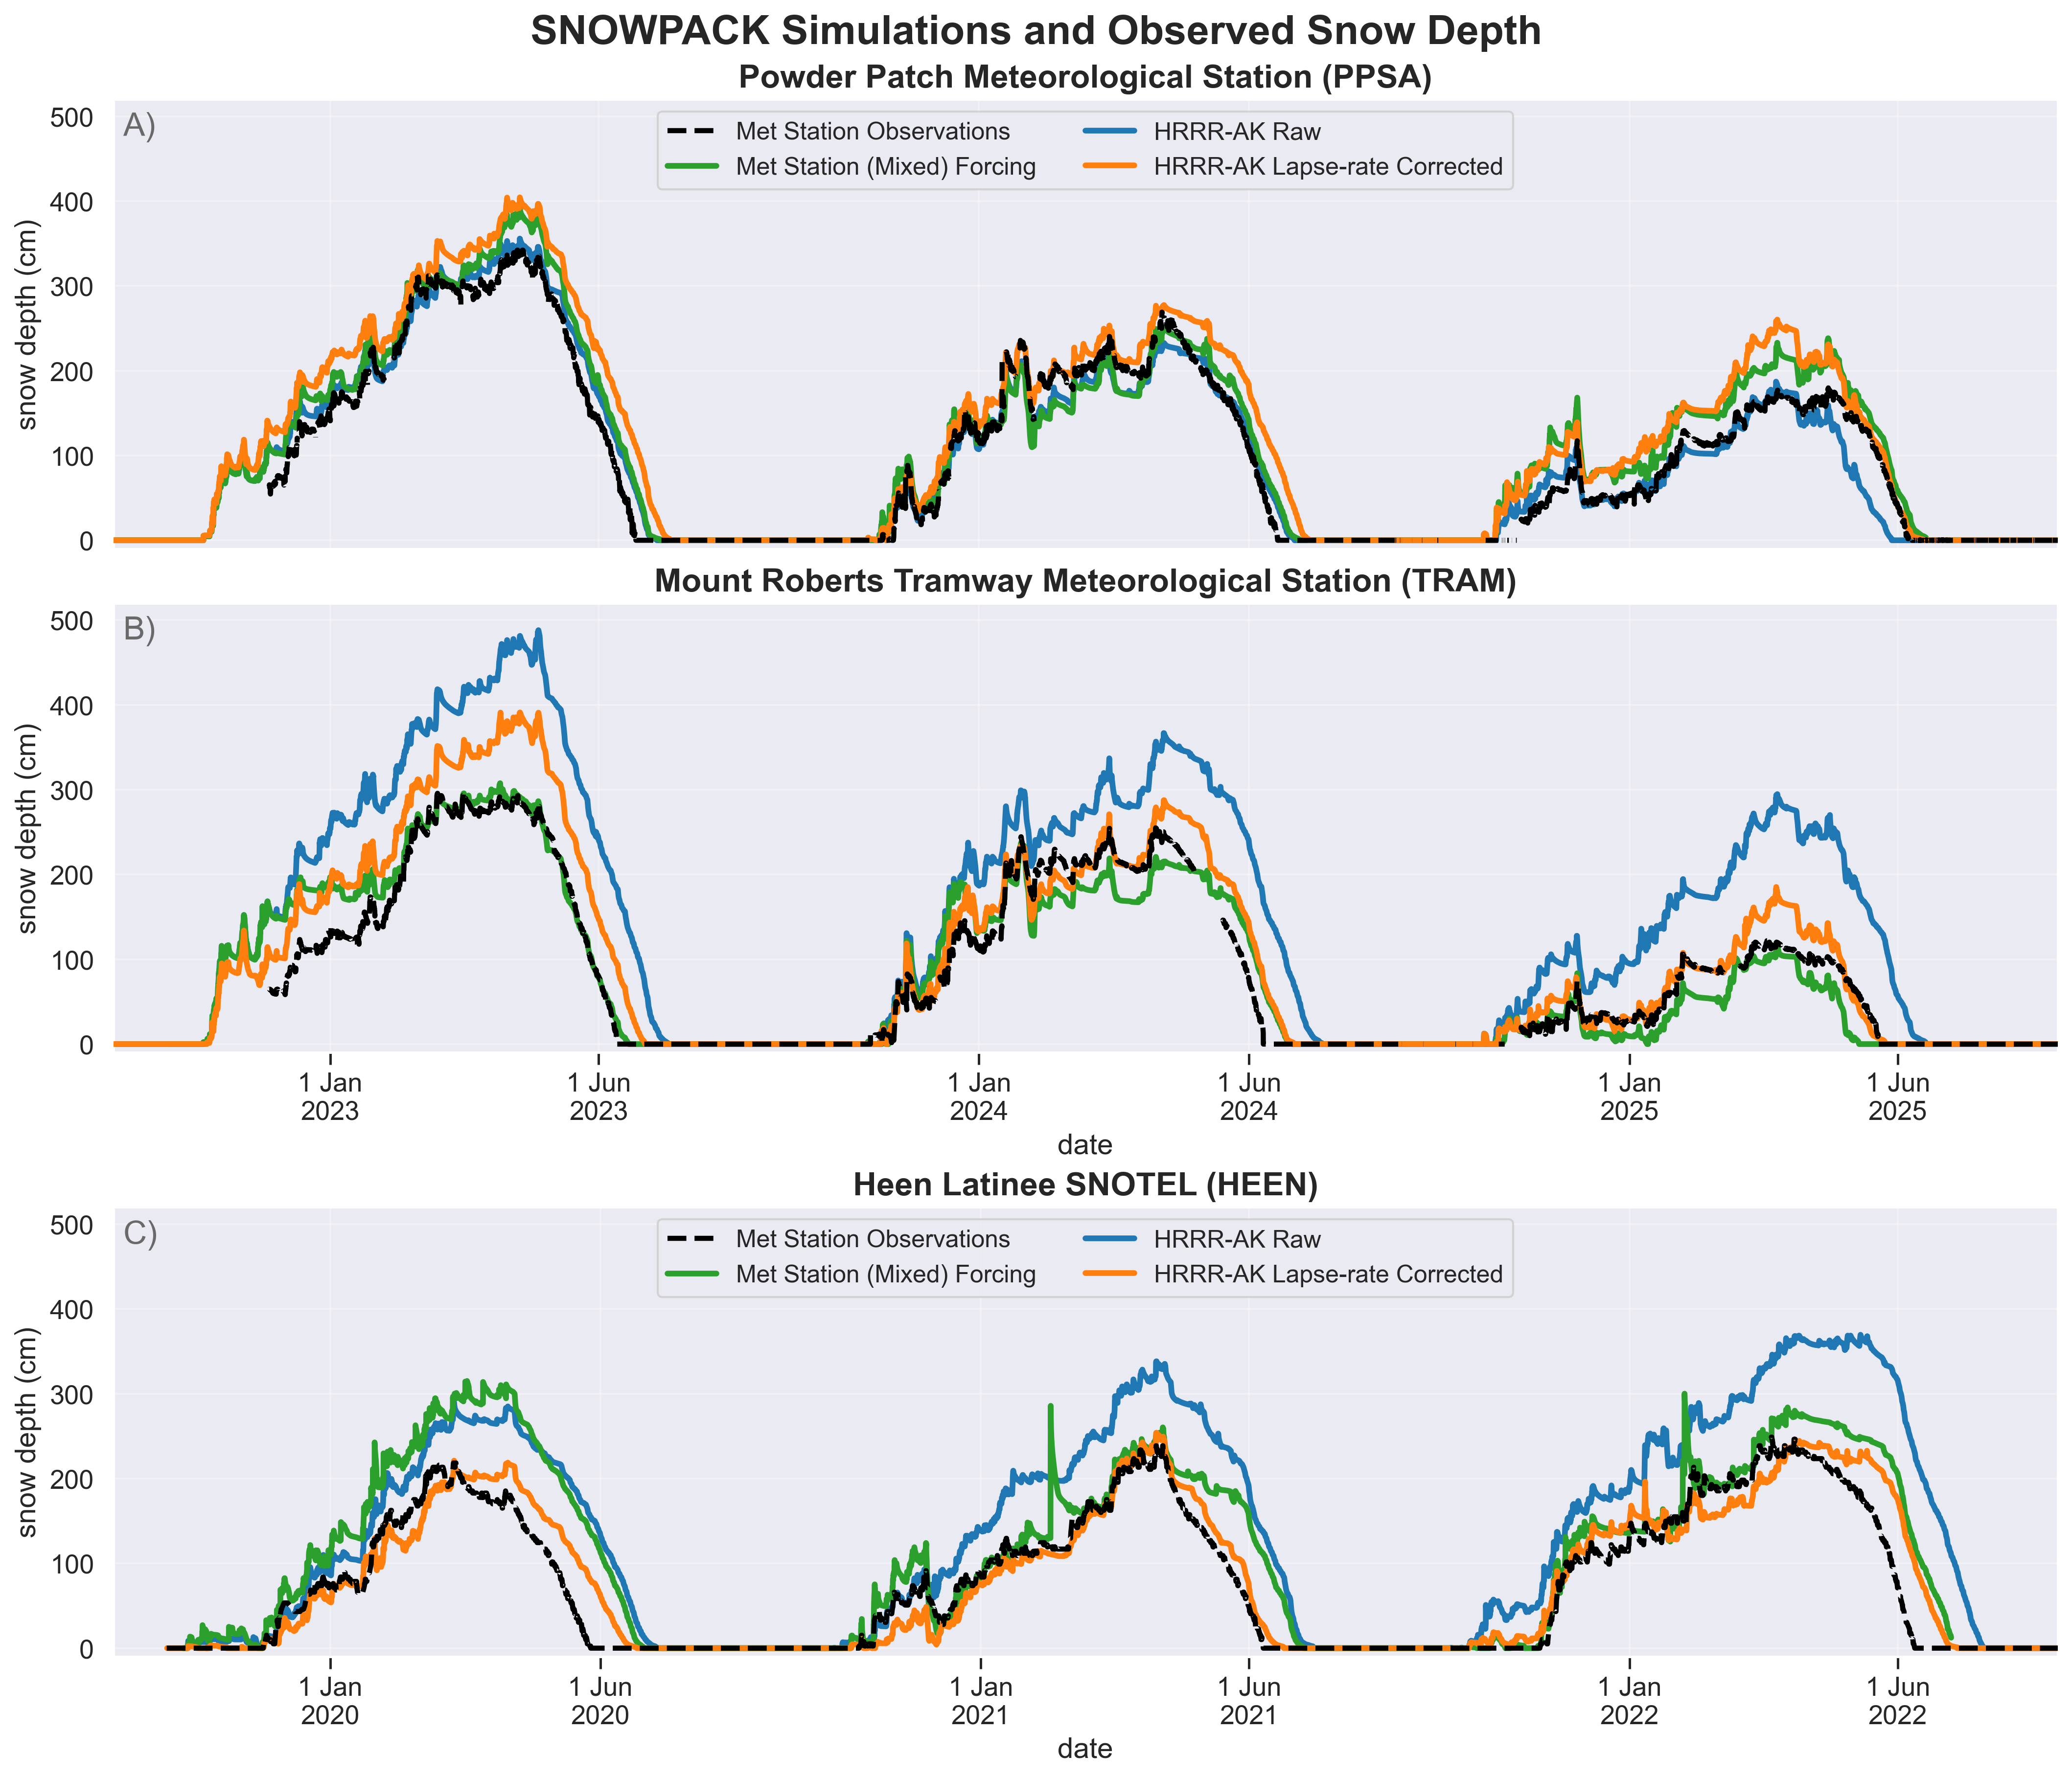

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ============================================================
# Select periods
# ============================================================

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"

# PPSA + TRAM -> WY2023-WY2025
modern_start = "2022-09-01"
modern_end   = "2025-08-30"

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)

ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(modern_start, modern_end)
)

ds_obs_tram_plot = ds_obs_tram.sel(
    time=slice(modern_start, modern_end)
)

# ------------------------------------------------------------
# HRRR-AK raw simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_heen_plot = ds_snowpack_hrrrak_heen.sel(
    timestamp=slice(heen_start, heen_end)
)

ds_snowpack_hrrrak_ppsa_plot = ds_snowpack_hrrrak_ppsa.sel(
    timestamp=slice(modern_start, modern_end)
)

ds_snowpack_hrrrak_tram_plot = ds_snowpack_hrrrak_tram.sel(
    timestamp=slice(modern_start, modern_end)
)

# ------------------------------------------------------------
# HRRR-AK lapse-rate simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

ds_snowpack_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(modern_start, modern_end)
    )
)

ds_snowpack_hrrrak_lapserate_tram_plot = (
    ds_snowpack_hrrrak_lapserate_tram.sel(
        timestamp=slice(modern_start, modern_end)
    )
)

# ------------------------------------------------------------
# Mixed met forcing simulations
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_heen_plot = ds_snowpack_met_hrrrak_heen.sel(
    timestamp=slice(heen_start, heen_end)
)

ds_snowpack_met_hrrrak_ppsa_plot = ds_snowpack_met_hrrrak_ppsa.sel(
    timestamp=slice(modern_start, modern_end)
)

ds_snowpack_met_hrrrak_tram_plot = ds_snowpack_met_hrrrak_tram.sel(
    timestamp=slice(modern_start, modern_end)
)

# ============================================================
# Adjustable presentation-style plotting parameters
# ============================================================

fig_width = 14
fig_height = 12
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 16
axis_label_fontsize = 14
tick_fontsize = 13
legend_fontsize = 12

model_linewidth = 2.8
obs_linewidth = 2.5

major_tick_length = 6
major_tick_width = 1.2

spine_width = 1.2

ymin = -10
ymax = 520

# ============================================================
# Colors
# ============================================================

hrrrak_color = "tab:blue"
hrrrak_lapserate_color = "tab:orange"
met_hrrrak_color = "tab:green"
obs_color = "black"

# ============================================================
# Site configuration
# ============================================================

site_data = [
    {
        "site_name": "Powder Patch Meteorological Station (PPSA)",
        "hrrr_ds": ds_snowpack_hrrrak_ppsa_plot,
        "hrrr_lapserate_ds": ds_snowpack_hrrrak_lapserate_ppsa_plot,
        "met_ds": ds_snowpack_met_hrrrak_ppsa_plot,
        "obs_ds": ds_obs_ppsa_plot,
        "xmin": modern_start,
        "xmax": modern_end,
        "panel_label": "A)",
    },
    {
        "site_name": "Mount Roberts Tramway Meteorological Station (TRAM)",
        "hrrr_ds": ds_snowpack_hrrrak_tram_plot,
        "hrrr_lapserate_ds": ds_snowpack_hrrrak_lapserate_tram_plot,
        "met_ds": ds_snowpack_met_hrrrak_tram_plot,
        "obs_ds": ds_obs_tram_plot,
        "xmin": modern_start,
        "xmax": modern_end,
        "panel_label": "B)",
    },
    {
        "site_name": "Heen Latinee SNOTEL (HEEN)",
        "hrrr_ds": ds_snowpack_hrrrak_heen_plot,
        "hrrr_lapserate_ds": ds_snowpack_hrrrak_lapserate_heen_plot,
        "met_ds": ds_snowpack_met_hrrrak_heen_plot,
        "obs_ds": ds_obs_heen_plot,
        "xmin": heen_start,
        "xmax": heen_end,
        "panel_label": "C)",
    },
]

# ============================================================
# Function to create one figure version
# ============================================================

def make_snowpack_figure(
    include_mixed=False,
    include_hrrr=False,
    include_lapserate=False,
    figure_title="SNOWPACK Simulations and Observed Snow Depth",
    output_filename=None,
):
    """
    Create one version of the three-panel snow-depth figure.

    Parameters
    ----------
    include_mixed : bool
        Plot the mixed meteorological-station forcing simulation.

    include_hrrr : bool
        Plot the raw HRRR-AK forcing simulation.

    include_lapserate : bool
        Plot the lapse-rate-corrected HRRR-AK simulation.

    figure_title : str
        Overall figure title.

    output_filename : str or None
        Filename for saving the figure. If None, the figure is not saved.
    """

    # --------------------------------------------------------
    # Create figure and axes
    # --------------------------------------------------------

    fig = plt.figure(
        figsize=(fig_width, fig_height),
        dpi=dpi,
        constrained_layout=True
    )

    ax1 = plt.subplot(3, 1, 1)
    ax2 = plt.subplot(3, 1, 2, sharey=ax1)
    ax3 = plt.subplot(3, 1, 3, sharey=ax1)

    axes = [ax1, ax2, ax3]

    # --------------------------------------------------------
    # Plot each site
    # --------------------------------------------------------

    for ax, site in zip(axes, site_data):

        # Observations are plotted first in every figure
        site["obs_ds"].hs.plot(
            ax=ax,
            color=obs_color,
            linestyle="--",
            linewidth=obs_linewidth,
            label="Met Station Observations",
            zorder=10,
        )

        # Mixed met forcing
        if include_mixed:
            site["met_ds"].HS_mod.plot(
                ax=ax,
                color=met_hrrrak_color,
                linewidth=model_linewidth,
                linestyle="-",
                label="Met Station (Mixed) Forcing",
                zorder=3,
            )

        # Raw HRRR-AK forcing
        if include_hrrr:
            site["hrrr_ds"].HS_mod.plot(
                ax=ax,
                color=hrrrak_color,
                linewidth=model_linewidth,
                linestyle="-",
                label="HRRR-AK Raw",
                zorder=2,
            )

        # Lapse-rate-corrected HRRR-AK forcing
        if include_lapserate:
            site["hrrr_lapserate_ds"].HS_mod.plot(
                ax=ax,
                color=hrrrak_lapserate_color,
                linewidth=model_linewidth,
                linestyle="-",
                label="HRRR-AK Lapse-rate Corrected",
                zorder=4,
            )

        # ----------------------------------------------------
        # Axis limits
        # ----------------------------------------------------

        ax.set_xlim(
            pd.Timestamp(site["xmin"]),
            pd.Timestamp(site["xmax"])
        )

        ax.set_ylim(ymin, ymax)

        # ----------------------------------------------------
        # Titles and axis labels
        # ----------------------------------------------------

        ax.set_title(
            site["site_name"],
            fontsize=subplot_title_fontsize,
            fontweight="bold"
        )

        ax.set_ylabel(
            "snow depth (cm)",
            fontsize=axis_label_fontsize
        )

        # ----------------------------------------------------
        # Tick formatting
        # ----------------------------------------------------

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=tick_fontsize,
            length=major_tick_length,
            width=major_tick_width
        )

        # Each axis needs its own locator and formatter
        ax.xaxis.set_major_locator(
            mdates.MonthLocator(bymonth=[1, 6])
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%-d %b\n%Y")
        )

        ax.set_xlabel(
            "date",
            fontsize=axis_label_fontsize
        )

        ax.tick_params(
            axis="x",
            which="major",
            bottom=True,
            labelbottom=True,
            labelsize=tick_fontsize,
            length=major_tick_length,
            width=major_tick_width
        )

        for label in ax.get_xticklabels():
            label.set_visible(True)

        # ----------------------------------------------------
        # Spine thickness and grid
        # ----------------------------------------------------

        for spine in ax.spines.values():
            spine.set_linewidth(spine_width)

        ax.grid(alpha=0.3)

        # ----------------------------------------------------
        # Panel label
        # ----------------------------------------------------

        ax.text(
            0.005,
            0.92,
            site["panel_label"],
            transform=ax.transAxes,
            fontsize=subplot_title_fontsize,
            color="dimgrey"
        )

    # --------------------------------------------------------
    # Remove x-axis ticks and label from panel A
    # --------------------------------------------------------

    ax1.set_xlabel("")

    ax1.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False
    )

    # --------------------------------------------------------
    # Legends
    # --------------------------------------------------------

    # Use two columns only when there are enough entries
    number_of_lines = (
        1
        + int(include_mixed)
        + int(include_hrrr)
        + int(include_lapserate)
    )

    legend_columns = 2 if number_of_lines >= 3 else 1

    ax1.legend(
        fontsize=legend_fontsize,
        loc="upper center",
        frameon=True,
        ncol=legend_columns
    )

    ax3.legend(
        fontsize=legend_fontsize,
        loc="upper center",
        frameon=True,
        ncol=legend_columns
    )

    # --------------------------------------------------------
    # Overall figure title
    # --------------------------------------------------------

    fig.suptitle(
        figure_title,
        fontsize=title_fontsize,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    if output_filename is not None:
        fig.savefig(
            output_filename,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, axes


# ============================================================
# Create figure 1: observations only
# ============================================================

fig1, axes1 = make_snowpack_figure(
    include_mixed=False,
    include_hrrr=False,
    include_lapserate=False,
    figure_title="Observed Snow Depth",
    output_filename="snowpack_01_observations_only.png",
)

# ============================================================
# Create figure 2: observations + mixed met model
# ============================================================

fig2, axes2 = make_snowpack_figure(
    include_mixed=True,
    include_hrrr=False,
    include_lapserate=False,
    figure_title="SNOWPACK Mixed Forcing Simulations and Observed Snow Depth",
    output_filename="snowpack_02_observations_and_mixed.png",
)

# ============================================================
# Create figure 3:
# observations + mixed met + HRRR-AK raw
# ============================================================

fig3, axes3 = make_snowpack_figure(
    include_mixed=True,
    include_hrrr=True,
    include_lapserate=False,
    figure_title="SNOWPACK Simulations and Observed Snow Depth",
    output_filename="snowpack_03_observations_mixed_hrrrak.png",
)

# ============================================================
# Create figure 4:
# observations + mixed met + raw HRRR-AK + lapse-rate HRRR-AK
# ============================================================

fig4, axes4 = make_snowpack_figure(
    include_mixed=True,
    include_hrrr=True,
    include_lapserate=True,
    figure_title="SNOWPACK Simulations and Observed Snow Depth",
    output_filename="snowpack_04_all_simulations.png",
)